# Guía 5 - Notebook de validación y entrega final
Este notebook ayuda a validar el dataset final y a generar evidencias para el informe técnico.

## 1. Importar librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Cargar dataset final
Verifica que el archivo CSV esté en la misma carpeta del notebook.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/jaidisplata/PRODEMIA/refs/heads/main/5-%20Documentaci%C3%B3n%20final%20del%20proceso%20IA/03_data/G5V1_dataset_final_segmentado.csv"

df = pd.read_csv(url)

print('Dimensiones:', df.shape)
df.head()

Dimensiones: (420, 19)


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono,Cluster
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media,CAMP_10,0,1
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta,CAMP_04,0,2
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta,CAMP_09,0,2
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1,0
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0,1


# Identificando el numero real de registros y columnas del dataset

In [ ]:
print("Número de clusters encontrados:")
print(df['Cluster'].nunique())

## 3. Validación técnica básica

In [9]:
print('Duplicados:', df.duplicated().sum())
print('Nulos totales:', df.isnull().sum().sum())
print('Tipos de dato:')
print(df.dtypes)

Duplicados: 0
Nulos totales: 0
Tipos de dato:
ID_Cliente                  object
Edad                         int64
IngresoMensual               int64
CantidadCompras              int64
ComprasUltimos12M            int64
AntiguedadMeses              int64
QuejasUltimos6M              int64
DiasDesdeUltimaCompra        int64
VisitasWebUltimoMes          int64
TiempoPromedioSesionMin    float64
CuponesUsados                int64
Ciudad                      object
CanalPreferido              object
ZonaResidencia              object
Segmento                    object
Satisfaccion                object
CodigoCampania              object
Abandono                     int64
Cluster                      int64
dtype: object


## 4. Validación de columnas importantes

In [10]:
columnas_esperadas = ['ID_Cliente','Edad','IngresoMensual','CantidadCompras','Cluster']
for col in columnas_esperadas:
    print(col, 'OK' if col in df.columns else 'FALTA')

ID_Cliente OK
Edad OK
IngresoMensual OK
CantidadCompras OK
Cluster OK


## 5. Distribución de clusters o variable final

Cluster
0    107
1    159
2    154
Name: count, dtype: int64

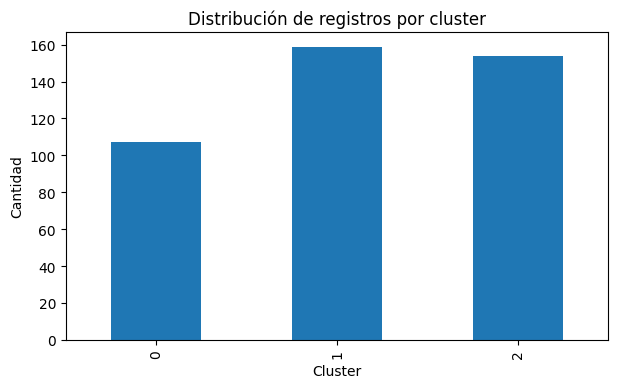

In [11]:
if 'Cluster' in df.columns:
    display(df['Cluster'].value_counts().sort_index())
    df['Cluster'].value_counts().sort_index().plot(kind='bar', figsize=(7,4))
    plt.title('Distribución de registros por cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print('No existe columna Cluster. Ajusta esta sección según tu análisis final.')

# VALIDACION DE CLUSTER

realizamos validación para verificar que ningún cluster esté vació

In [ ]:
conteo = df['Cluster'].value_counts().sort_index()

if (conteo == 0).any():
    print("Existen clusters vacíos")
else:
    print("Todos los clusters contienen registros")

## 6. Resumen para el informe
Completa esta interpretación con tus palabras.

In [ ]:
print('Redacta aquí una interpretación:')
print('- El dataset final contiene...')
print('- La validación permitió identificar ...')
print('- Los resultados principales fueron ...')
print('- Las limitaciones más importantes son ...')

Redacta aquí una interpretación:
- El dataset final contiene ...
- La validación permitió identificar ...
- Los resultados principales fueron ...
- Las limitaciones más importantes son ...


El dataset final contiene toda la información consolidada de los clientes además de la variable Cluster genrada por el modelo de segmentación,se observa un conjunto de datos con una estructura compacta, consistente, limpia porque no contiene duplicados, valores nulos, garantizando datos de calidad aptos para realizar el análisis.

la validación técnica y basica que se realiza al dataset, permitió identificar que las variables utilizadas requeridas se encuentran disponibles, que los tipos de datos son adecuados y coherentes con el tipo de datos, por otra parte la columna Cluster fue creada correctamente durante la segmentación.


Los resultados principales se dieron a través de la asignación de cada cliente a un grupo especifico y la generación de segmentos diferenciados según sus características y comportamientos. la distribución de registros por cluster evidencia que el proceso de agrupamiento fue ejecutado correctamente y permite realizar análisis comparativos entre segmentos.


Las limitaciones más importantes son que la calidad de los Clusters depende de las variables  seleccionadas, del preprocesamiento realizado y de la configuración del algoritmo K-Means. Además, los grupos obtenidos representan patrones estadísticos que requieren interpretación de negocio para generar conclusiones y acciones concretas. 